# Lab: Relationships in Space and Time

Florida red tide is caused primarily by high concentrations of the microscopic alga *Karenia brevis*. The organism can produce toxins that harm marine life and cause respiratory irritation near affected shorelines. A bloom does not remain in one fixed place: winds and currents can move and disperse it while its concentration changes.

This lab examines part of the unusually long 2017–2019 Florida red-tide bloom. From June through November 2018, documented bloom concentrations expanded beyond southwest Florida and were detected in the Panhandle and, for part of the period, along the Atlantic coast.

## Learning goals

By the end of this lab, you should be able to:

- prepare and check a temporal feature;
- summarize observations by month;
- create and interpret an interactive time-series plot;
- map observations using exact latitude and longitude coordinates;
- animate spatial observations through time with Plotly Express; and
- distinguish documented sample locations from the complete extent of an environmental event.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The course dataset was prepared from the Florida Fish and Wildlife Conservation Commission's [Historic Harmful Algal Bloom Events 2015–2023 GIS layer](https://gis.myfwc.com/mapping/rest/services/Open_Data/Historic_Harmful_Algal_Bloom_Events_2015___2023/MapServer/12). It contains **7,292 water samples** collected from June 1 through November 30, 2018.

These are sampling records, not a continuous measurement of every part of Florida's coastal water. Sampling included routine monitoring, research, and additional event-response sampling when a bloom was suspected or already known.

# Step 1: Question

> **How did the location and concentration of documented Florida red tide change from June through November 2018?**

**During which month do you predict the greatest share of samples reached bloom concentration?**

Your answer: I predict August because the warmer summer conditions may help the bloom grow.

**Where around Florida do you predict bloom concentrations will appear by the end of this period?**

Your answer: I predict the higher bloom concentrations will appear along Florida’s Coast.

# Step 2: Data

## 1. Import the libraries

Import Pandas and Plotly Express using their conventional aliases.

In [1]:
# Write your code here.
import pandas as pd
import plotly.express as px

## 2. Read the data

Read `data/florida_red_tide_samples_june_november_2018.csv` into a DataFrame named `red_tide`. Use `parse_dates=["sample_date"]` so Pandas stores the sample date as a datetime rather than text.

In [3]:
# Write your code here.
red_tide = pd.read_csv(
    "data/florida_red_tide_samples_june_november_2018.csv",
    parse_dates=["sample_date"]
)

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [8]:
# Write your code here.
display(red_tide.head())
display(red_tide.tail())
red_tide.info()
display(red_tide.isnull().sum())

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.36043,-80.06847,0.5,0.0,Not present/background
1,2018-06-01,Gumbo Limbo Nature Center (Lake Wyman),26.36751,-80.07118,0.5,0.0,Not present/background
2,2018-06-01,Bay Dock (Sarasota Bay),27.33160,-82.57790,0.5,5000.0,Very low
3,2018-06-01,New Pass Dock (Sarasota Bay),27.33375,-82.57938,0.5,1000.0,Not present/background
4,2018-06-01,Dixie Highway Bridge; E of (Indian River),27.85566,-80.49085,1.3,0.0,Not present/background


,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
7287,2018-11-29,Brooks Bridge; W of (Santa Rosa Sound),30.400800,-86.600800,0.1,0.0,Not present/background
7288,2018-11-30,Gasparilla Island; 10 mi W of,26.722583,-82.366933,0.5,20667.0,Low
7289,2018-11-30,Gasparilla Island; 13 mi W of,26.760700,-82.475550,0.5,391020.0,Medium
7290,2018-11-30,Bay Dock (Sarasota Bay),27.331600,-82.577900,0.5,534000.0,Medium
7291,2018-11-30,New Pass Dock (Sarasota Bay),27.333750,-82.579380,0.5,274000.0,Medium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7292 entries, 0 to 7291
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   sample_date                     7292 non-null   datetime64[ns]
 1   location                        7292 non-null   object        
 2   latitude                        7292 non-null   float64       
 3   longitude                       7292 non-null   float64       
 4   sample_depth_m                  7259 non-null   float64       
 5   karenia_brevis_cells_per_liter  7292 non-null   float64       
 6   abundance_category              7292 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 398.9+ KB


sample_date                        0
location                           0
latitude                           0
longitude                          0
sample_depth_m                    33
karenia_brevis_cells_per_liter     0
abundance_category                 0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `sample_date` | Calendar date on which the water sample was collected |
| `location` | Description or name of the sampling location |
| `latitude` | Sample latitude in decimal degrees north |
| `longitude` | Sample longitude in decimal degrees; values west of the prime meridian are negative |
| `sample_depth_m` | Sampling depth in meters |
| `karenia_brevis_cells_per_liter` | Number of *Karenia brevis* cells measured per liter of water |
| `abundance_category` | FWC concentration category calculated from the cell count |

The FWC categories are:

- **Not present/background:** 0–1,000 cells per liter
- **Very low:** over 1,000–10,000
- **Low:** over 10,000–100,000
- **Medium:** over 100,000–1,000,000
- **High:** over 1,000,000

For this lab, a sample is at **bloom concentration** when it contains at least 100,000 cells per liter.

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `sample_date` | Temporal | datetime64[ns] | 0 |
| `location` | Categorical | object | 0 |
| `latitude` | Quantitative | float64 | 0 |
| `longitude` | Quantitative | float64 | 0 |
| `sample_depth_m` | Quantitative | float64 | 33 |
| `karenia_brevis_cells_per_liter` | Quantitative | float64 | 0 |
| `abundance_category` | Categorical | object | 0 |

**What does one row represent?**

Your answer: One row represents one red tide water sample collected at a specific location and date.

**Why can the same location appear in more than one row?**

Your answer: The same location can appear more than once because samples were collected there on different dates.

# Step 3: Operation

## 4. Sort the samples by date

Sort `red_tide` by `sample_date`. Use `inplace=True` to modify the existing DataFrame rather than creating another one.

In [9]:
# Write your code here.
red_tide.sort_values(
    by="sample_date",
    inplace=True
)

## 5. Create monthly time features

Create `month` by using datetime methods to convert each `sample_date` to a monthly period and then back to a timestamp. The resulting timestamp represents the first day of its month and can be sorted chronologically.

Then create `month_label` with `.dt.strftime("%B %Y")`. This creates readable labels such as `June 2018` for the animation.

In [10]:
# Write your code here.
red_tide["month"] = red_tide["sample_date"].dt.to_period("M").dt.to_timestamp()
red_tide["month_label"] = red_tide["sample_date"].dt.strftime("%B %Y")

## 6. Identify samples at bloom concentration

Create a Boolean feature named `bloom_level` that is `True` when `karenia_brevis_cells_per_liter` is at least 100,000 and `False` otherwise.

In [14]:
# Write your code here.
red_tide["bloom_level"] = (
    red_tide["karenia_brevis_cells_per_liter"] >= 100000
)

## 7. Create a monthly summary

Group the records by `month` and use `.agg()` to calculate:

- `total_samples`: the number of cell-count records in each month; and
- `bloom_samples`: the sum of `bloom_level` in each month.

Summing works because Pandas evaluates `True` as 1 and `False` as 0. Use `.reset_index()` to return `month` to a regular column.

Then calculate `percent_bloom` as the number of bloom samples divided by the total number of samples, multiplied by 100. Display `monthly_summary`.

In [16]:
# Write your code here.
monthly_summary = (
    red_tide
    .groupby("month")
    .agg(
        total_samples=("bloom_level", "count"),
        bloom_samples=("bloom_level", "sum")
    )
    .reset_index()
)

monthly_summary["percent_bloom"] = (
    monthly_summary["bloom_samples"]
    / monthly_summary["total_samples"]
    * 100
)

display(monthly_summary)

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


## 8. Prepare the map data

To keep the spatial figures readable, create `map_data` containing samples with more than 10,000 cells per liter. Use `.copy()` because `map_data` will be a separate DataFrame used for the figures.

Create `month_order` from the unique `month_label` values. Because the rows were sorted first, the labels will be in chronological order. Also create `abundance_order` containing `Low`, `Medium`, and `High` in that order.

Samples at or below 10,000 cells per liter remain in `red_tide` and in the monthly summary; they are omitted only from the maps.

In [17]:
# Write your code here.
map_data = red_tide[
    red_tide["karenia_brevis_cells_per_liter"] > 10000
].copy()

month_order = map_data["month_label"].unique().tolist()

abundance_order = ["Low", "Medium", "High"]

# Step 4: Check

## 9. Check the prepared data

Display:

- the number of rows;
- the earliest and latest dates;
- the number of unique months;
- missing-value counts for the date, coordinates, cell count, and depth; and
- descriptive statistics for latitude, longitude, depth, and cell count.

In [18]:
# Write your code here.
print("Number of rows:", len(red_tide))
print("Earliest date:", red_tide["sample_date"].min())
print("Latest date:", red_tide["sample_date"].max())
print("Number of unique months:", red_tide["month"].nunique())

display(
    red_tide[
        [
            "sample_date",
            "latitude",
            "longitude",
            "karenia_brevis_cells_per_liter",
            "sample_depth_m"
        ]
    ].isnull().sum()
)

display(
    red_tide[
        [
            "latitude",
            "longitude",
            "sample_depth_m",
            "karenia_brevis_cells_per_liter"
        ]
    ].describe()
)

Number of rows: 7292
Earliest date: 2018-06-01 00:00:00
Latest date: 2018-11-30 00:00:00
Number of unique months: 6


sample_date                        0
latitude                           0
longitude                          0
karenia_brevis_cells_per_liter     0
sample_depth_m                    33
dtype: int64

,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter
count,7292.000000,7292.000000,7259.000000,7.292000e+03
mean,27.428306,-82.253707,1.326353,5.472636e+05
std,1.297599,1.452258,4.368422,3.276337e+06
min,24.455000,-87.325914,0.000000,0.000000e+00
25%,26.576700,-82.683950,0.500000,0.000000e+00
50%,27.308970,-82.337920,0.500000,0.000000e+00
75%,28.047500,-81.408525,0.500000,3.066700e+04
max,30.701200,-79.948800,71.000000,9.000000e+07


**Why do the 33 missing depth values not require us to remove those records from this analysis?**

Your answer: The missing depth values do not need to be removed because depth is not being used to measure the bloom concentration or map the sample locations.

## 10. Check the aggregation

Display `monthly_summary`, then compare the sum of `total_samples` with the number of rows in `red_tide`. Compare the sum of `bloom_samples` with the sum of `bloom_level` in the original DataFrame.

In [19]:
# Write your code here.
display(monthly_summary)

print("Total samples from summary:", monthly_summary["total_samples"].sum())
print("Rows in red_tide:", len(red_tide))

print("Bloom samples from summary:", monthly_summary["bloom_samples"].sum())
print("Bloom samples in red_tide:", red_tide["bloom_level"].sum())

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


Total samples from summary: 7292
Rows in red_tide: 7292
Bloom samples from summary: 1426
Bloom samples in red_tide: 1426


**What kind of preparation error could be revealed if either pair of totals did not match?**

Your answer: It could show that some rows were accidentally left out, duplicated, or grouped incorrectly when the data was prepared.

# Step 5: Evidence

## 11. Plot the monthly percentage at bloom concentration

Use `px.line()` with `monthly_summary` to plot `month` against `percent_bloom`. Show markers and add a question-focused title and readable axis labels.

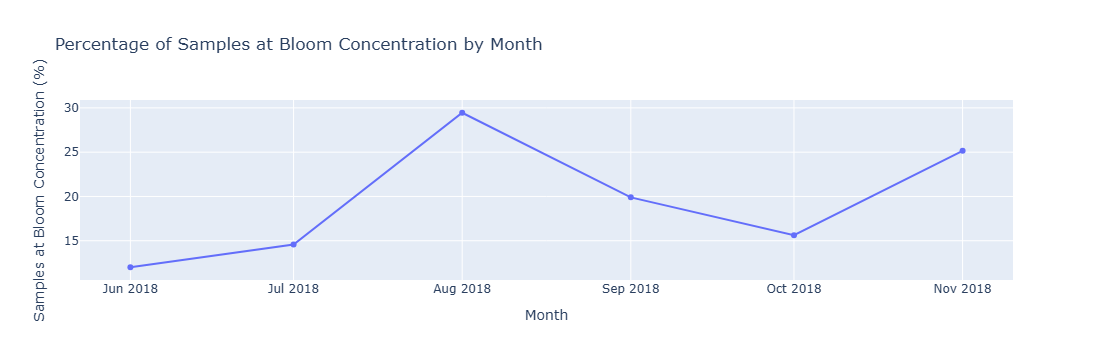

In [20]:
# Write your code here.
fig = px.line(
    monthly_summary,
    x="month",
    y="percent_bloom",
    markers=True,
    title="Percentage of Samples at Bloom Concentration by Month",
    labels={
        "month": "Month",
        "percent_bloom": "Samples at Bloom Concentration (%)"
    }
)

fig.show()

**During which month was the percentage of samples at bloom concentration highest?**

Your answer: August 2018 had the highest percentage of samples at bloom concentration, at about 29.4%.

**What temporal pattern do you observe from June through November?**

Your answer: The percentage increased from June to August, dropped through October, then increased again in November.

## 12. Map the documented sample locations

Create a static `px.scatter_map()` using `map_data`.

- Use the exact `latitude` and `longitude` features.
- Map `abundance_category` to color.
- Use `location` as the hover name.
- Include `sample_date` and the cell count in `hover_data`.
- Use `abundance_order` in `category_orders`.
- Choose three ordered colors for Low, Medium, and High abundance.
- Use `zoom=4.5`, center the map at latitude 27.7 and longitude -82.3, use the `open-street-map` style, and set `height=650`.

The `abundance_category` values were already defined in the course dataset from the FWC cell-count ranges introduced in the data dictionary:

- **Low:** over 10,000–100,000 cells per liter
- **Medium:** over 100,000–1,000,000 cells per liter
- **High:** over 1,000,000 cells per liter

Because `map_data` contains only samples above 10,000 cells per liter, these are the three categories that appear in the map legend. You do not need to calculate the categories again.



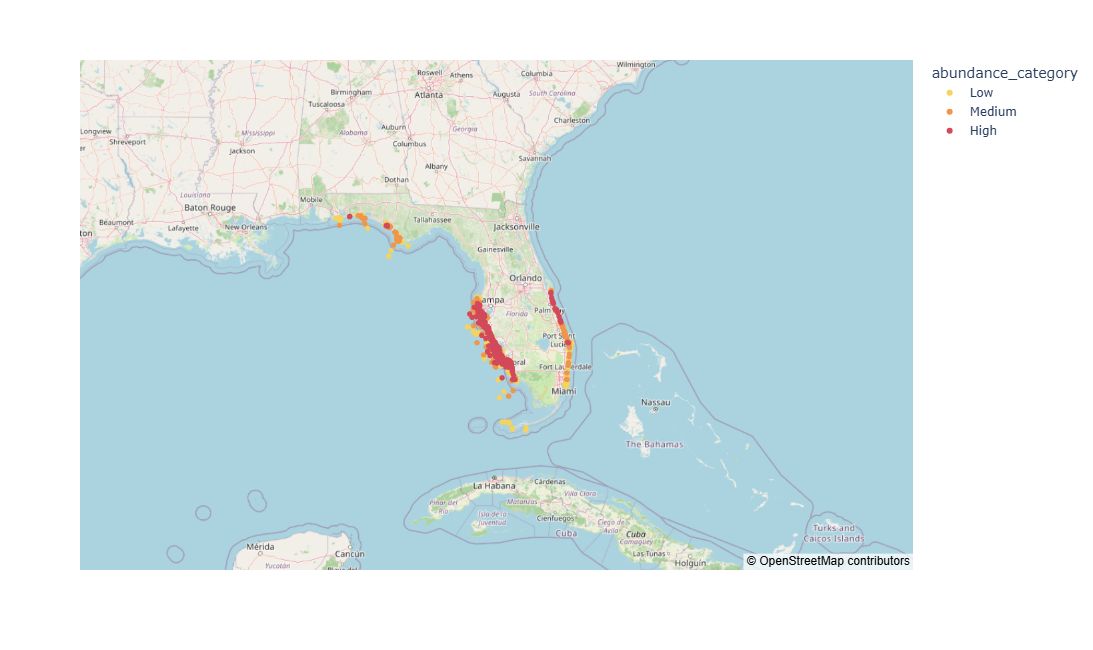

In [21]:
# Write your code here.
fig = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data=["sample_date", "karenia_brevis_cells_per_liter"],
    category_orders={"abundance_category": abundance_order},
    color_discrete_sequence=["#f4d35e", "#ee964b", "#d1495b"],
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650
)

fig.show()

**What spatial pattern is visible in the static map?**

Your answer: Most of the higher red tide concentrations are clustered along the Florida Gulf Coast.

**What important temporal information is difficult to recover from the static map?**

Your answer: The static map does not clearly show how the location and concentration of red tide change from month to month.

## 13. Animate the documented sample locations

Re-create the spatial figure with `animation_frame="month_label"`. Add the chronological `month_order` to `category_orders` so the slider follows June through November.

Keep the map center, zoom, height, category order, and colors fixed. This makes changes among frames easier to interpret as changes in the observations rather than changes in the display.

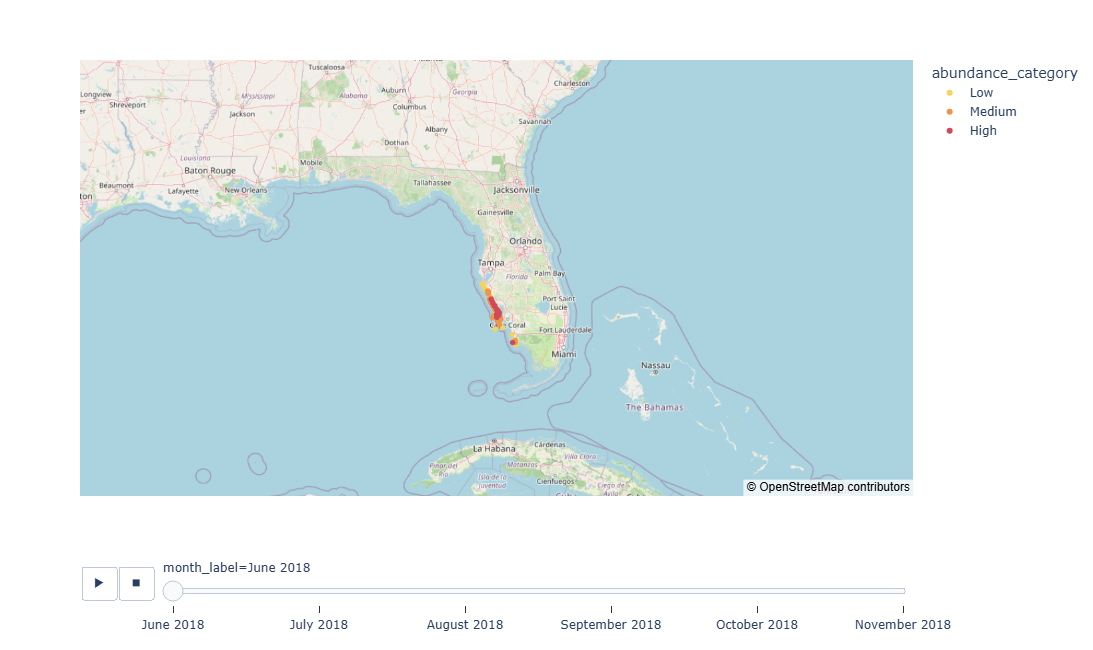

In [22]:
# Write your code here.
fig = px.scatter_map(
    map_data,
    lat="latitude",
    lon="longitude",
    color="abundance_category",
    hover_name="location",
    hover_data=["sample_date", "karenia_brevis_cells_per_liter"],
    animation_frame="month_label",
    category_orders={
        "month_label": month_order,
        "abundance_category": abundance_order
    },
    color_discrete_sequence=["#f4d35e", "#ee964b", "#d1495b"],
    zoom=4.5,
    center={"lat": 27.7, "lon": -82.3},
    map_style="open-street-map",
    height=650
)

fig.show()

**How did the documented bloom's geographic pattern change from June through November?**

Your answer: The bloom started mostly along the Southwest Florida coast. Then spread farther along the Gulf into other parts of Florida as it approached fall and winter.

**Which figure makes the timing of geographic expansion easiest to see?**

 Your answer: The animated map makes the timing of the geographic expansion easiest to see because it shows the changes month by month.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from both the time-series plot and the animated map.**

Your answer:

**Why does the animation show documented sample locations rather than the complete geographic boundary of the bloom?**

 Your answer: The animation only shows locations where samples were collected, so it cannot show the full boundary of the bloom in areas that were not sampled.

**Why should the monthly percentages not be interpreted as the percentage of all Florida coastal water affected by red tide?**

Your answer: The percentages only describe the samples that were collected, not all of Florida’s coastal waters. Some areas may have been sampled more often than others.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: I used ChatGPT to help check my code and answers, in comparison to my notebook.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give every figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Distinguish sample locations from the complete extent of the bloom.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.